## Chapter 1: Singular Value Decomposition

### Section 1.1: Overview

In [1]:
# Computing SVD
import numpy as np
import pandas as pd
X = np.random.rand(5, 3) #I'm creating a random 5x3 matrix
U, S, VT = np.linalg.svd(X, full_matrices = True) #Setting full_matrices to False would give us a reduced SVD
UHat, SHat, VTHat = np.linalg.svd(X, full_matrices = False) #Here's our aforementioned Economy SVD

In [2]:
print(f"{U} \n")
print(f"{S} \n")
print(VT)

[[-0.47781627 -0.42140147  0.06469586 -0.70973382 -0.29360647]
 [-0.3395331   0.56085469  0.29158223  0.19836635 -0.66767499]
 [-0.52224256  0.09332718 -0.82187623  0.20255073  0.04522615]
 [-0.322475   -0.63273803  0.28803796  0.64034055 -0.05148371]
 [-0.52884919  0.31431743  0.39031762 -0.07658895  0.68066833]] 

[2.40299998 0.90101951 0.46098866] 

[[-0.60906207 -0.52928328 -0.59067979]
 [-0.77326061  0.23064633  0.59065244]
 [-0.17638433  0.8164934  -0.54975184]]


In [3]:
print(f"{UHat} \n")
print(f"{SHat} \n")
print(VTHat)

[[-0.47781627 -0.42140147  0.06469586]
 [-0.3395331   0.56085469  0.29158223]
 [-0.52224256  0.09332718 -0.82187623]
 [-0.322475   -0.63273803  0.28803796]
 [-0.52884919  0.31431743  0.39031762]] 

[2.40299998 0.90101951 0.46098866] 

[[-0.60906207 -0.52928328 -0.59067979]
 [-0.77326061  0.23064633  0.59065244]
 [-0.17638433  0.8164934  -0.54975184]]


### Section 5.2 SVD Image Compression
 

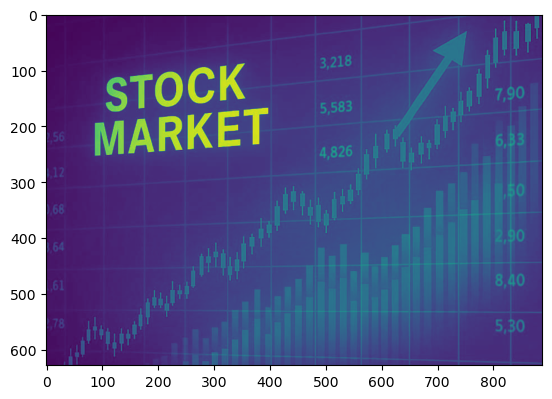

In [4]:
#First, we load the image
import matplotlib 
import matplotlib.pyplot as plt

from matplotlib.image import imread
A = imread(r"C:\Users\saami\OneDrive\Desktop\ML & Dynamical Systems Code\data\stock_market.jpg")
X = np.mean(A, -1); #Converting to grayscale
img = plt.imshow(X)

In [5]:
#import os

#print(os.getcwd())
#print(os.listdir())

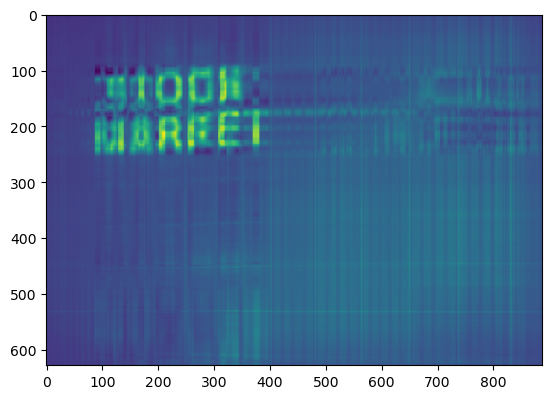

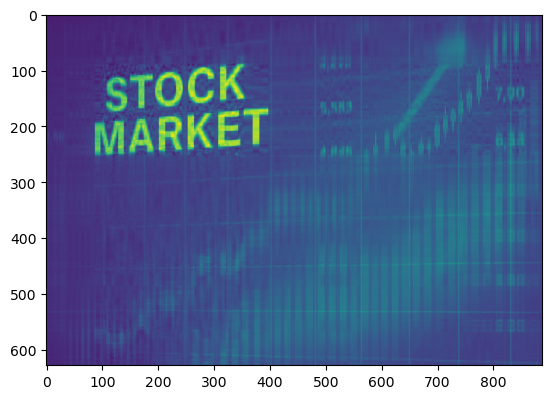

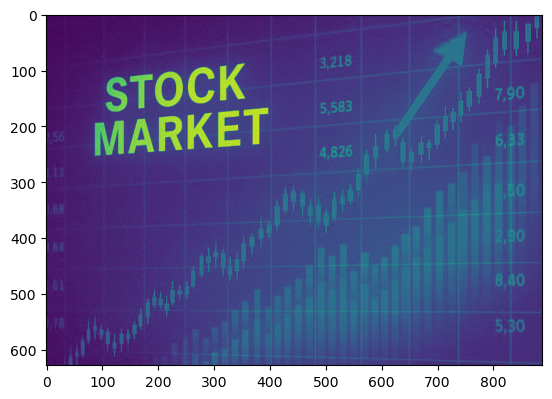

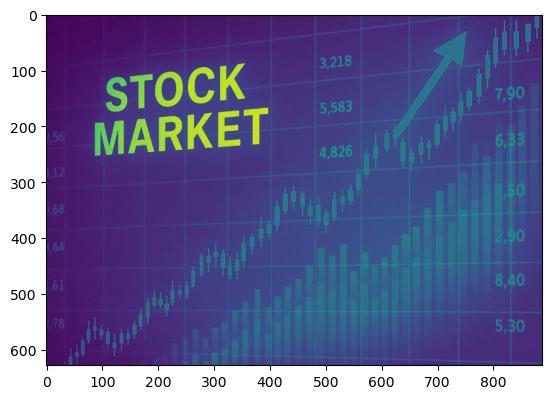

In [6]:
#Take SVD
U, S, VT = np.linalg.svd(X, full_matrices=False)
S = np.diag(S)

#Approximate matrix with truncated SVD for various r

for r in (5, 20, 100, 200):
    Xapprox = U[:, :r] @ S[0:r, :r] @ VT[:r, :]
    img = plt.imshow(Xapprox)
    plt.show()

<bound method Axes.set of <Axes: xlabel='Rank', ylabel='Cumulative Sum'>>

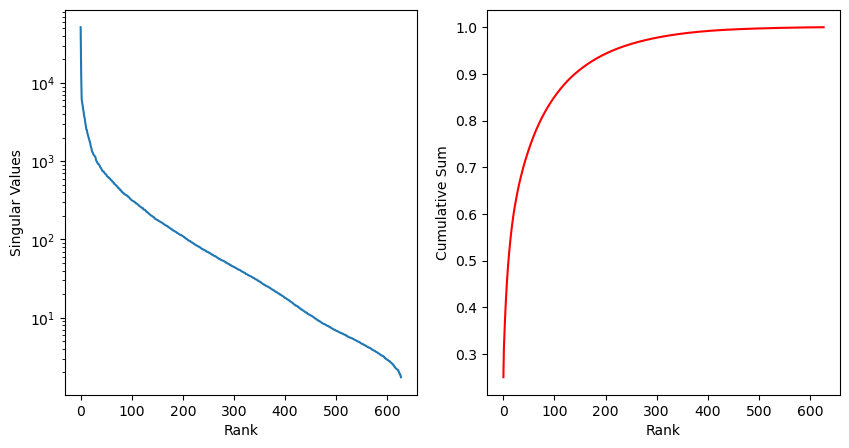

In [7]:
#Plot singular values and cumulative sum
#Create 2 graphs
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].semilogy(np.diag(S)) #Convenient for converting to log scale graph
ax[0].set_ylabel('Singular Values')
ax[0].set_xlabel('Rank')

ax[1].plot(np.cumsum(np.diag(S))/np.sum(np.diag(S)), color = 'red')
ax[1].set_ylabel('Cumulative Sum')
ax[1].set_xlabel('Rank')
ax[1].set

### Section 1.4 Pseudo-inverse

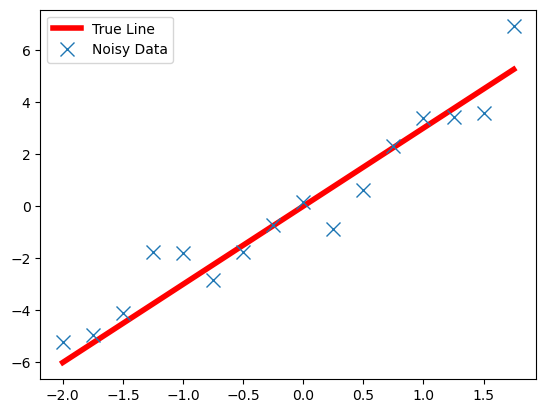

In [8]:
#Least-Squares fit of noisy data in fig 1.9

x = 3 #This is the true slope of the line

a = np.arange(-2, 2, 0.25)
a = a.reshape(-1, 1)
b = x*a + np.random.randn(*a.shape) #Adding noise to the data to simulate real-world data

plt.plot(a, x*a, 'r-', label = 'True Line', linewidth = 4)

plt.plot(a, b, 'x', label = 'Noisy Data', markersize = 10, linewidth = 6)

plt.legend()

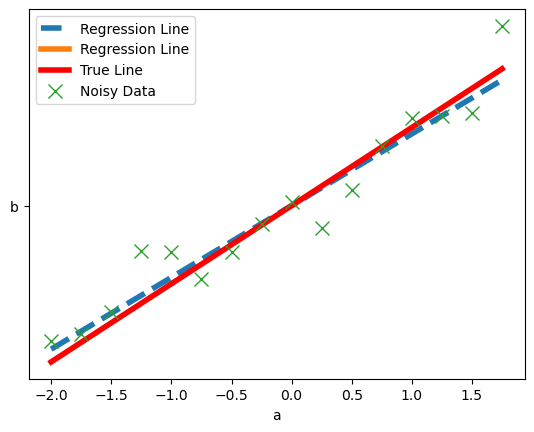

In [9]:
#Now we're going to use a least squares approximation with SVD and see how it matches up with the true line

U, S, VT = np.linalg.svd(a, full_matrices=False)
xtilde = VT.T @ np.linalg.inv(np.diag(S)) @ U.T @ b #Least Square fit using inverse solution

plt.plot(a, xtilde*a, '--', 'b', label = 'Regression Line', linewidth = 4)

#I'm now overlaying the previous graph on top just for a visual comparison of the two lines

plt.plot(a, x*a, 'r-', label = 'True Line', linewidth = 4)
plt.plot(a, b, 'x', label = 'Noisy Data', markersize = 10, linewidth = 6)

plt.xlabel('a')

plt.legend()
#You can see that the regression line is a good approximation of the true line, even with the noise in the data. This demonstrates the power of SVD.

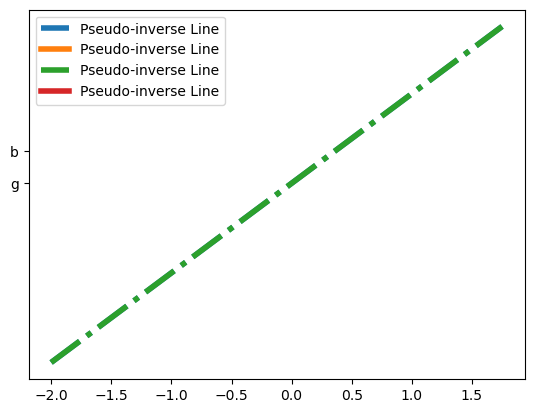

In [10]:
#Alternate least squares formulation

#Note, if x is a 1x1 matrix, then dot product and matrix multiplication are equivalent here

xtilde2 = np.linalg.pinv(a) @ b #Least Square fit using pseudo-inverse

plt.plot(a, xtilde2*a, '-.', 'g', label = 'Pseudo-inverse Line', linewidth = 4)
plt.plot(a, a @ xtilde2, '-.', 'b', label = 'Pseudo-inverse Line', linewidth = 4)

plt.legend()

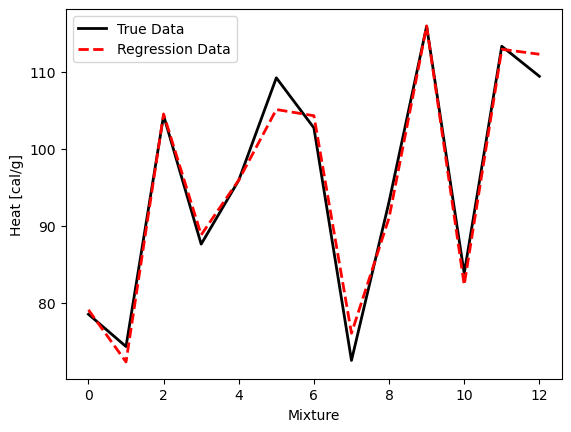

In [11]:
#Multiple linear regression for cement data

#Load dataset
A = pd.read_csv(r"C:\Users\saami\OneDrive\Desktop\ML & Dynamical Systems Code\data\Book_Data\hald_ingredients.csv", header = None)
b = pd.read_csv(r"C:\Users\saami\OneDrive\Desktop\ML & Dynamical Systems Code\data\Book_Data\hald_heat.csv", header = None)

#Using good old SVD to solve Ax = b

U, S, VT = np.linalg.svd(A, full_matrices = 0)
#x = VT.T @ np.linalg.inv(np.diag(S)) @ U.T @ b
x = np.linalg.pinv(A) @ b #pinv is much more convenient than writing ou the whole inverse solution

plt.plot(b, 'k', linewidth = 2, label = 'True Data')
plt.plot(A @ x, 'r--', linewidth = 2, label = 'Regression Data')

plt.xlabel('Mixture')
plt.ylabel('Heat [cal/g]')

plt.legend()

In [12]:
#Example 2: Determining significance of factors
    #Boston Housing Market
    #See book github, if this doesn't come up in the homework, I will work through it myself

### Section 1.5 Principal Component Analysis (PCA)

In [13]:
#Generate noisy cloud  of data
xCenter = np.array([2,1]) #center of data (Mean)
sig = np.array([2, 0.5]) #Principal axes [Directions of maximum variance]

theta = np.pi/3 #Angle of rotation of cloud
R = np.array([[np.cos(theta), -np.sin(theta)], 
            [np.sin(theta), np.cos(theta)]]) #Rotation matrix

nPoints = 10000 #Create 10,000 points in the cloud

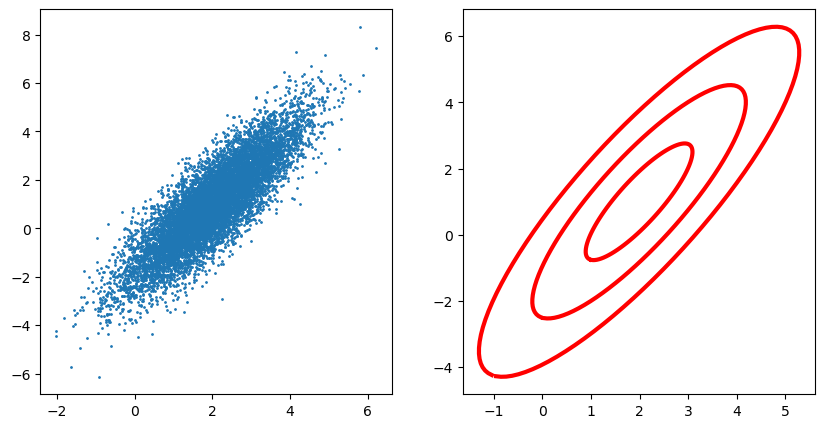

In [14]:
X = R @ np.diag(sig) @ np.random.randn(2, nPoints) + np.diag(xCenter) @ np.ones((2, nPoints)) #What I think is happening is in the first term you're 
#Creating a cloud that is stretched and compressed according to principal axes and then shifted by the center values due to the addition of the second term
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.plot(X[0, :], X[1, :], '.', markersize = 2)

#Find principal components (SVD)
Xavg = np.mean(X, axis = 1) #Compute mean
B = X - np.tile(Xavg, (nPoints, 1)).T #Mean subtracted data

#Find Principal Components
U, S, VT = np.linalg.svd(B/np.sqrt(nPoints-1), full_matrices = False) #SVD of mean subtracted data
theta = 2 * np.pi * np.arange(0, 1, 0.01) #Create a range of angles

Xstd = U @ np.diag(S) @ np.array([np.cos(theta), np.sin(theta)]) 

ax2.plot(Xavg[0] + Xstd[0,:], Xavg[1] + Xstd[1, :], '-', color = 'red', linewidth = 3)
ax2.plot(Xavg[0] + 2 * Xstd[0,:], Xavg[1] + 2 * Xstd[1, :], '-', color = 'red', linewidth = 3)
ax2.plot(Xavg[0] + 3 * Xstd[0,:], Xavg[1] + 3 * Xstd[1, :], '-', color = 'red', linewidth = 3)


Text(0, 0.5, 'PC3')

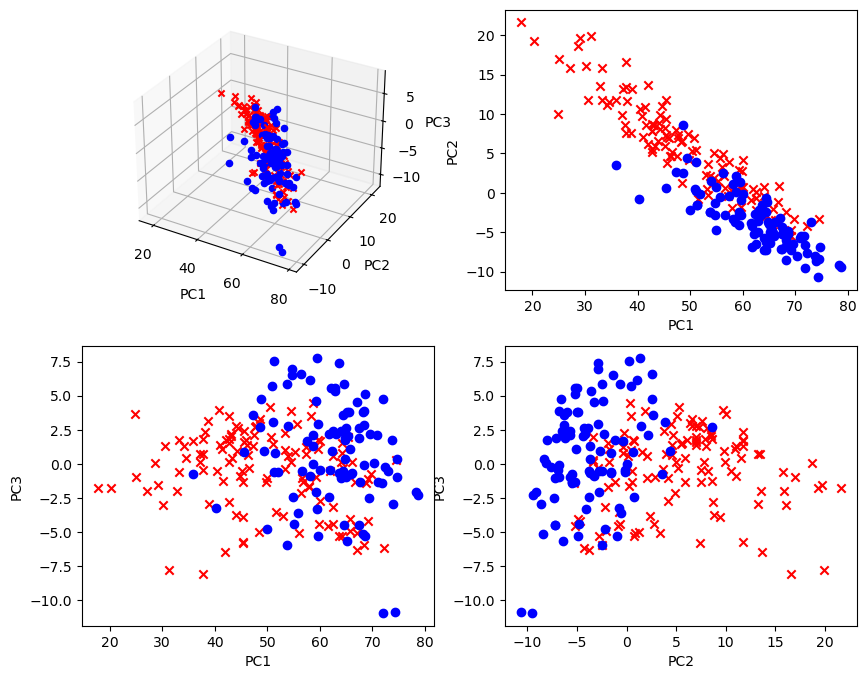

In [15]:
#Example: Computing PCA of Ovarian Cancer Dataset
fig = plt.figure(figsize=(10, 8))

ax1 = fig.add_subplot(221, projection='3d')
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)

obs = pd.read_csv(r"C:\Users\saami\OneDrive\Desktop\ML & Dynamical Systems Code\data\Book_Data\ovariancancer_obs.csv")
f = pd.read_csv(r"C:\Users\saami\OneDrive\Desktop\ML & Dynamical Systems Code\data\Book_Data\ovariancancer_grp.csv")

U, S, VT = np.linalg.svd(obs, full_matrices = False)

for j in range(obs.shape[0]):
    x = VT[0, :] @ obs.iloc[j, :].T
    y = VT[1, :] @ obs.iloc[j, :].T
    z = VT[2, :] @ obs.iloc[j, :].T

    if f.iloc[j, 0] == 'Cancer': 
        ax1.scatter(x, y, z, marker = 'x', color = 'r')
        ax2.scatter(x, y, marker = 'x', color = 'r')
        ax3.scatter(x, z, marker = 'x', color = 'r')
        ax4.scatter(y, z, marker = 'x', color = 'r')
    else: 
        ax1.scatter(x, y, z, marker = 'o', color = 'b')
        ax2.scatter(x, y, marker = 'o', color = 'b')
        ax3.scatter(x, z, marker = 'o', color = 'b')
        ax4.scatter(y, z, marker = 'o', color = 'b')

ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_zlabel('PC3')

ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')

ax3.set_xlabel('PC1')
ax3.set_ylabel('PC3')

ax4.set_xlabel('PC2')
ax4.set_ylabel('PC3')

It's obvious by the graphs that PC1 and PC2 have the strongest explanatory power, whereas PC3 is significantly weaker

### Section 1.6: Eigenfaces 

In [16]:
#Don't run the code in this section, it's very computationally intensive

C:\Users\saami\AppData\Local\Temp\ipykernel_32720\3848245144.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m = int(mat_contents['m'])
C:\Users\saami\AppData\Local\Temp\ipykernel_32720\3848245144.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  n = int(mat_contents['n'])


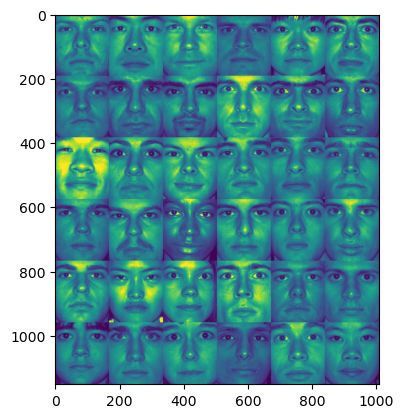

In [17]:
#Plotting image from each person in the Yale database
from scipy.io import loadmat
mat_contents = loadmat(r"C:\Users\saami\OneDrive\Desktop\ML & Dynamical Systems Code\data\Book_Data\allFaces.mat")
faces = mat_contents['faces']
m = int(mat_contents['m'])
n = int(mat_contents['n'])
nfaces = np.ndarray.flatten(mat_contents['nfaces'])

allPersons = np.zeros((n*6, m*6))
count = 0

for j in range(6):
    for k in range(6):
        allPersons[j * n : (j+1) * n, k * m : (k+1) * m] = np.reshape(faces[:, np.sum(nfaces[:count])], (m, n)).T
        count += 1

img = plt.imshow(allPersons)

In [18]:
#Computing eigenfaces on the mean-subtracted data

#We use the first 36 for training data
trainingFaces = faces[:, 0:np.sum(nfaces[0:36])]
avgFace = np.mean(trainingFaces, axis = 1) # size n*m by 1

#Compute eigenfaces on mean-subtracted training data
X = trainingFaces - np.tile(avgFace, (trainingFaces.shape[1], 1)).T

U, S, VT = np.linalg.svd(X, full_matrices = 0)
img_avg = ax1.imshow(np.reshape(avgFace, (m,n)).T)
img_u1 = ax2.imshow(np.reshape(U[:, 0], (m,n)).T)

In [ ]:
#Approximate test image omitted from training data
testFace = faces[:, np.sum(nfaces[:36])] # Person 37
testFaceMS = testFace - avgFace
#r_list = [25, 50]
reconFace = avgFace + U[:, :25] @ U[:, :25].T @ testFaceMS
img = plt.imshow(np.reshape(reconFace, (m,n)).T)

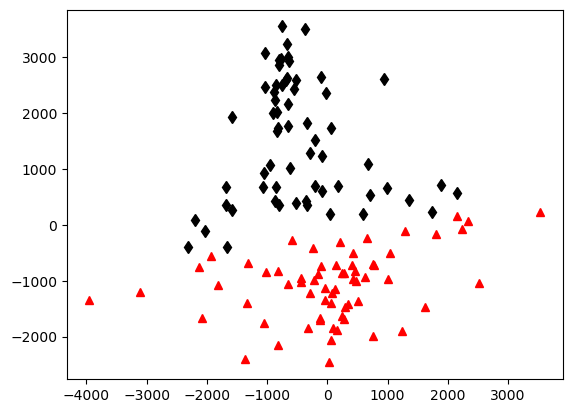

In [ ]:
#Project images for two specific people onto the 5th and 6th eigenfaces to illustrate potential for automated classification

P1num = 2 #Person number 2
P2num = 7 #Person number 7

P1 = faces[:, np.sum(nfaces[:(P1num-1)]):np.sum(nfaces[:P1num])]
P2 = faces[:, np.sum(nfaces[:(P2num-1)]):np.sum(nfaces[:P2num])]

P1 = P1 - np.tile(avgFace, (P1.shape[1], 1)).T
P2 = P2 - np.tile(avgFace, (P2.shape[1], 1)).T

PCAmodes = [5, 6] #Project onto PCA nodes 5 & 6
PCACoordsP1 = U[:, PCAmodes - np.ones_like(PCAmodes)].T @ P1
PCACoordsP2 = U[:, PCAmodes - np.ones_like(PCAmodes)].T @ P2

plt.plot(PCACoordsP1[0, :], PCACoordsP1[1, :], 'd', color = 'k')
plt.plot(PCACoordsP2[0, :], PCACoordsP2[1, :], '^', color = 'r')

### Section 1.7: Truncation & Alignment 

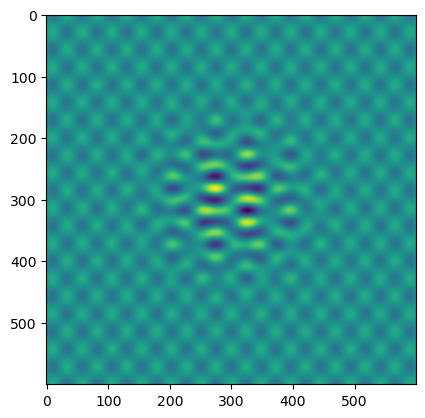

In [16]:
#Exmple: Comparison of various thresholding approaches on noisy low-rank data

t = np.arange(-3, 3, 0.01)

Utrue = np.array([np.cos(17*t) * np.exp(-t**2), np.sin(11*t)]).T
Strue = np.array([[2, 0], [0, 0.5]])
Vtrue = np.array([np.sin(5*t) * np.exp(-t**2), np.cos(13*t)]).T

X = Utrue @ Strue @ Vtrue.T
plt.imshow(X)

[[ 0.73391023 -0.62384545 -0.26785839 ... -0.72810186  1.32264197
   0.47505452]
 [ 0.21525227  0.13125451  0.53307197 ... -1.37123028  0.68935106
   0.27775773]
 [ 1.2864723  -1.19943575 -1.0107294  ...  0.11815612  1.13419771
  -0.18246402]
 ...
 [-0.6691276   1.65418791 -0.63698247 ... -0.90916701  0.57640933
  -0.68574843]
 [-0.86791969  1.58422682  0.72468203 ... -0.23510934  1.18530357
  -0.58318944]
 [ 1.019206   -1.15532994 -0.68806813 ...  1.6847417  -1.81193748
   0.45605077]]


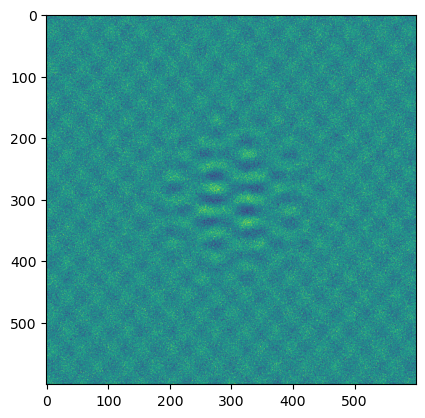

In [20]:
#Now we'll contaminate the signal with noise to give us a less clear image
sigma = 1
Xnoisy = X + sigma*np.random.randn(*X.shape)
plt.imshow(Xnoisy)

print(np.random.randn(*X.shape)) #It seems that this generates a random noisy matrix, which multiplied by the standard deviation, creates our noise addition to the true matrix

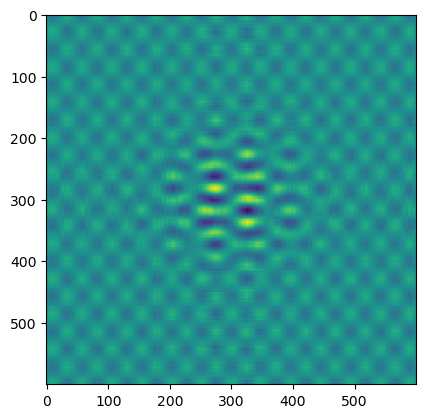

In [24]:
#Truncate using optimal hard threshold

U, S, VT = np.linalg.svd(Xnoisy, full_matrices=0)

N = Xnoisy.shape[0]
cutoff = (4/np.sqrt(3)) * np.sqrt(N) * sigma #Hard threshold
r = np.max(np.where(S > cutoff))

Xclean = U[:, :(r+1)] @ np.diag(S[:(r+1)]) @ VT[:(r+1), :]
plt.imshow(Xclean)

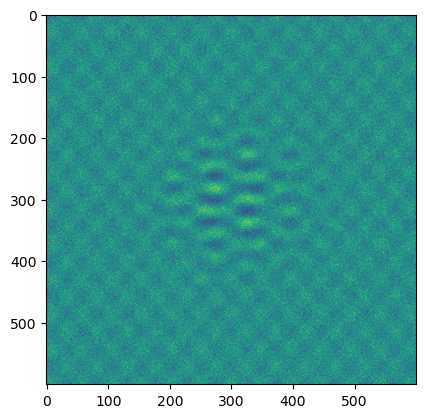

In [27]:
#Truncate to keep 90% of cumulative sum
cdS = np.cumsum(S) / np.sum(S) #cumulative energy
r90 = np.min(np.where(cdS > 0.90)) #Find r to find 90% sum

X90 = U[:, :(r90+1)] @ np.diag(S[:(r90+1)]) @ VT[:(r90+1), :]
plt.imshow(X90)

### Section 1.8: Randomized Singular Value Decomposition

 Now we're moving away from deterministic forms to something that's more adaptable to larger-scale data

 It's also less computationally intensive


In [ ]:
# We're starting off with a randomized SVD algorithm function to approximate high-resolution images
# Code is simple, no optimization for speed, data transfer, or accuracy

def rSVD(X, r, q, p):
    # Step 1: Sample column space of X with P matrix
    ny = X.shape[1]
    P = np.random.randn(ny, r+p)
    Z = X @ P 
    for k in range(q): 
        Z = X @ (X.T @ Z) # This is an implementation of power iterations to increase singular value decay faster
        print(k)

    Q, R = np.linalg.qr(Z, mode = 'reduced')

    # Step 2: Compute SVD on projected Y = Q.T @ X
    Y = Q.T @ X
    UY, S, VT = np.linalg.svd(Y, full_matrices = 0)
    U = Q @ UY

    return U, S, VT

In [30]:
# Now we're using the function to compute the randomized SVD of the image
A = imread(r"C:\Users\saami\OneDrive\Desktop\ML & Dynamical Systems Code\data\Book_Data\jupiter.jpg")
X = np.mean(A, axis = 2) #RGB --> Grayscale
U, S, VT = np.linalg.svd(X, full_matrices = 0) #Full SVD

r = 400 # Rank target
q = 1 # Only one power iteration
p = 5 # Oversampling parameter
rU, rS, rVT = rSVD(X, r, q, p)

## Reconstruction
XSVD = U[:, :(r+1)] @ np.diag(S[:(r+1)]) @ VT[:(r+1), :]
errSVD = np.linalg.norm(X-XSVD, ord = 2)/np.linalg.norm(X, ord = 2)

XrSVD = rU[:, :(r+1)] @ np.diag(rS[:(r+1)]) @ rVT[:(r+1), :]
err_rSVD = np.linalg.norm(X-XrSVD, ord = 2)/np.linalg.norm(X, ord = 2)

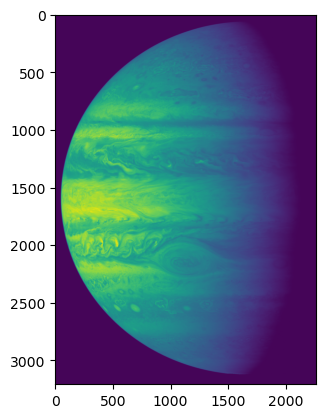

In [32]:
plt.imshow(XSVD)

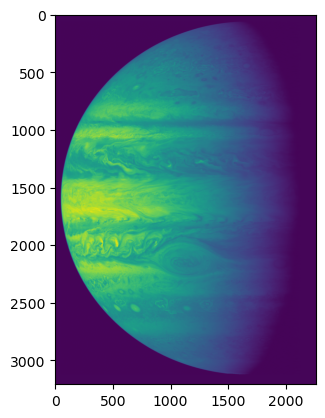

In [33]:
plt.imshow(XrSVD)

In [36]:
print(f'Error of SVD {errSVD}')
print(f'Error of rSVD {err_rSVD}')

Error of SVD 0.00039233052613762027
Error of rSVD 0.0005126834832863621


### Section 1.9: Tensor Decompositions and N-Way Data Arrays

In [43]:
# Creating tensor data

x = np.arange(-5, 5.1, 0.1)
y = np.arange(-6, 6.01, 0.1)
t = np.arange(0, 10*np.pi + 0.1, 0.1)
X, Y, T = np.meshgrid(x,y,t)

A = np.exp(-(X**2 + 0.5*Y**2)) * np.cos(2*T) + (np.divide(np.ones_like(X), np.cosh(X)) * np.tanh(X) * np.exp(-0.2*Y**2)) * np.sin(T) #The data is generated from this spatio-temporal function


In [53]:
!pip install tensorly
from tensorly.decomposition import parafac
import tensorly as tl

In [ ]:
#Textbook creates 2-factor model, I did a 3-factor
for element in parafac(A, 3):
    print(element)
#A1, A2  = parafac(A, 2)

[1. 1. 1.]
[array([[ 8.06918920e-05, -2.41152870e-02,  1.13589366e-17],
       [ 1.02003445e-04, -3.05952870e-02,  1.44110251e-17],
       [ 1.28239315e-04, -3.86615669e-02,  1.82101254e-17],
       [ 1.60251529e-04, -4.86594504e-02,  2.29187612e-17],
       [ 1.98892787e-04, -6.09983061e-02,  2.87295295e-17],
       [ 2.44909128e-04, -7.61607446e-02,  3.58693723e-17],
       [ 2.98752884e-04, -9.47125265e-02,  4.46041469e-17],
       [ 3.60271218e-04, -1.17313097e-01,  5.52434363e-17],
       [ 4.28204055e-04, -1.44726620e-01,  6.81455111e-17],
       [ 4.99394878e-04, -1.77833341e-01,  8.37223183e-17],
       [ 5.67575880e-04, -2.17641051e-01,  1.02444333e-16],
       [ 6.21532001e-04, -2.65296370e-01,  1.24845055e-16],
       [ 6.42372636e-04, -3.22095519e-01,  1.51524867e-16],
       [ 5.99541502e-04, -3.89494163e-01,  1.83153916e-16],
       [ 4.45070522e-04, -4.69115889e-01,  2.20473573e-16],
       [ 1.05430290e-04, -5.62758772e-01,  2.64295954e-16],
       [-5.29853061e-04, -6.